In [4]:
"""
Cell 1 — Install + imports
"""
!pip -q install pandas numpy scikit-learn tqdm

import re
import json
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, hamming_loss

In [5]:
"""
Cell 2 — File paths + quick existence check
"""
FEATURES_CSV = "/content/spotify_emotion_feature_multi.csv"
MULTILABEL_CSV = "/content/spotifyid_emotion_multilabel.csv"
RAW_TXT = "/content/rawdataset.txt"

import os
for p in [FEATURES_CSV, MULTILABEL_CSV, RAW_TXT]:
    print(p, "->", "FOUND" if os.path.exists(p) else "MISSING")

/content/spotify_emotion_feature_multi.csv -> FOUND
/content/spotifyid_emotion_multilabel.csv -> FOUND
/content/rawdataset.txt -> FOUND


In [6]:
"""
Cell 3 — Load the datasets

What this cell does:
- Reads the two CSV datasets into pandas DataFrames.
- Reads the rawdataset.txt documentation into a string (for reference).

Why:
- We need: features (numeric Spotify audio features) + multilabel emotion truth.
- The text file is just documentation; it won’t be used in modeling.
"""
df_features = pd.read_csv(FEATURES_CSV)
df_multi = pd.read_csv(MULTILABEL_CSV)

with open(RAW_TXT, "r", encoding="utf-8", errors="ignore") as f:
    raw_doc = f.read()

print("df_features shape:", df_features.shape)
print("df_multi shape:", df_multi.shape)
print("rawdataset.txt length:", len(raw_doc))

df_features shape: (82950, 16)
df_multi shape: (156931, 4)
rawdataset.txt length: 3021


In [7]:
"""
Cell 4 — Inspect columns + peek at the data
"""
print("df_features columns:\n", df_features.columns.tolist())
display(df_features.head(3))

print("\n\ndf_multi columns:\n", df_multi.columns.tolist())
display(df_multi.head(3))

df_features columns:
 ['track_id', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence', 'emotion', 'title', 'artist']


,track_id,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,emotion,title,artist
0,2g8HN35AnVGIk7B8yMucww,0.43,0.78,0.575,0.0,9,0.143,-7.247,0,0.273,84.491997,4,0.773,fear,Big Poppa,The Notorious B.I.G.
1,2g8HN35AnVGIk7B8yMucww,0.43,0.78,0.575,0.0,9,0.143,-7.247,0,0.273,84.491997,4,0.773,sadness,Big Poppa,The Notorious B.I.G.
2,2g8HN35AnVGIk7B8yMucww,0.43,0.78,0.575,0.0,9,0.143,-7.247,0,0.273,84.491997,4,0.773,disgust,Big Poppa,The Notorious B.I.G.




df_multi columns:
 ['track_id', 'emotion', 'title', 'artist']


,track_id,emotion,title,artist
0,1xlyVmdCo5lMRIzuMlAUF7,joy,I'm Glad There Is You,Julie London
1,2ceJL4FSlQMsqXwBcm3Gxo,joy,Rain,Alphawezen
2,3aEnfH7rR8UXf468PSLkgi,joy,Whispers,Ian Brown


In [8]:
"""
Cell 5 — Normalize column names + auto-detect key columns

What this cell does:
- Standardizes column names (lowercase, underscores).
- Tries to detect:
  - track ID column in each file (e.g., track_id / spotify_id)
  - label column in df_multi (e.g., emotion / emotions / labels)
"""
def normalize_cols(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [c.strip().lower().replace(" ", "_") for c in out.columns]
    return out

df_features = normalize_cols(df_features)
df_multi = normalize_cols(df_multi)

def find_first(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

id_candidates = ["track_id", "spotify_id", "spotify_track_id", "id"]
label_candidates = ["emotion_labels", "emotions", "labels", "emotion", "emotion_label"]

features_id_col = find_first(df_features.columns, id_candidates)
multi_id_col = find_first(df_multi.columns, id_candidates)
label_col = find_first(df_multi.columns, label_candidates)

print("Detected ID col in df_features:", features_id_col)
print("Detected ID col in df_multi:", multi_id_col)
print("Detected label col in df_multi:", label_col)

# If any of these are None, set them manually here:
# features_id_col = "_____"
# multi_id_col = "_____"
# label_col = "_____"

Detected ID col in df_features: track_id
Detected ID col in df_multi: track_id
Detected label col in df_multi: emotion


In [9]:
"""
Cell 6 — Merge into one modeling table (features + true multilabel emotions)

What this cell does:
- Renames the ID columns to a shared name ('track_id').
- Inner-joins features with multilabel truth labels.
"""
if features_id_col is None or multi_id_col is None:
    raise ValueError("Could not auto-detect track id columns. Set features_id_col and multi_id_col manually.")

if label_col is None:
    raise ValueError("Could not auto-detect label column in df_multi. Set label_col manually.")

df = (
    df_features.rename(columns={features_id_col: "track_id"})
    .merge(df_multi.rename(columns={multi_id_col: "track_id"}), on="track_id", how="inner")
)

print("Merged df shape:", df.shape)
display(df.head(3))

Merged df shape: (233130, 19)


,track_id,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,emotion_x,title_x,artist_x,emotion_y,title_y,artist_y
0,2g8HN35AnVGIk7B8yMucww,0.43,0.78,0.575,0.0,9,0.143,-7.247,0,0.273,84.491997,4,0.773,fear,Big Poppa,The Notorious B.I.G.,fear,Big Poppa,The Notorious B.I.G.
1,2g8HN35AnVGIk7B8yMucww,0.43,0.78,0.575,0.0,9,0.143,-7.247,0,0.273,84.491997,4,0.773,fear,Big Poppa,The Notorious B.I.G.,sadness,Big Poppa,The Notorious B.I.G.
2,2g8HN35AnVGIk7B8yMucww,0.43,0.78,0.575,0.0,9,0.143,-7.247,0,0.273,84.491997,4,0.773,fear,Big Poppa,The Notorious B.I.G.,disgust,Big Poppa,The Notorious B.I.G.


In [10]:
"""
Cell 7 — Clean labels + build 'true_labels' for feature-only modeling

What this cell does:
1) Chooses the correct emotion label column after merge (emotion_y).
2) Drops metadata columns (title/artist) so we enforce "features-only".
3) Converts per-row labels into a normalized list format for scoring.
   - Here each row has ONE label, so true_labels becomes [label].

Why:
- Your merge created emotion_x and emotion_y (not 'emotion').
- We want the label used for evaluation to be explicit and consistent.
- We remove title/artist to guarantee the model sees only feature values.
"""
# 1) Pick the label column explicitly (based on your merged output)
label_col = "emotion_y"   # <-- this is the key fix

# 2) Define allowed emotion set
EMOTIONS = ["joy", "sadness", "anger", "fear", "surprise", "disgust"]

# 3) Drop metadata columns to enforce feature-only setting
cols_to_drop = [c for c in ["title_x", "artist_x", "title_y", "artist_y", "emotion_x"] if c in df.columns]
df = df.drop(columns=cols_to_drop)

# 4) Normalize labels and create list form
df[label_col] = df[label_col].astype(str).str.lower().str.strip()
df = df[df[label_col].isin(EMOTIONS)].copy()

df["true_labels"] = df[label_col].apply(lambda x: [x])
df["n_true"] = df["true_labels"].apply(len)

print("Using label_col =", label_col)
print("df shape after cleaning:", df.shape)
display(df[["track_id", label_col, "true_labels"]].head(10))

Using label_col = emotion_y
df shape after cleaning: (233130, 16)


,track_id,emotion_y,true_labels
0,2g8HN35AnVGIk7B8yMucww,fear,[fear]
1,2g8HN35AnVGIk7B8yMucww,sadness,[sadness]
2,2g8HN35AnVGIk7B8yMucww,disgust,[disgust]
3,2g8HN35AnVGIk7B8yMucww,anger,[anger]
4,2g8HN35AnVGIk7B8yMucww,fear,[fear]
5,2g8HN35AnVGIk7B8yMucww,sadness,[sadness]
6,2g8HN35AnVGIk7B8yMucww,disgust,[disgust]
7,2g8HN35AnVGIk7B8yMucww,anger,[anger]
8,2g8HN35AnVGIk7B8yMucww,fear,[fear]
9,2g8HN35AnVGIk7B8yMucww,sadness,[sadness]


In [11]:
"""
Cell - 8
Build a track-level dataset (one row per track)
with true multi-label sets.

Why:
- Your current merged df repeats tracks across multiple emotion_y rows.
- For multi-label evaluation, it is cleaner to evaluate per track.
"""
feature_cols = [
    "acousticness","danceability","energy","instrumentalness","key",
    "liveness","loudness","mode","speechiness","tempo","time_signature","valence"
]

# group emotions per track
labels_per_track = (
    df.groupby("track_id")[label_col]
      .apply(lambda s: sorted(set(s.tolist())))
      .rename("true_labels")
      .reset_index()
)

# keep features once per track (they should be identical across duplicates)
features_per_track = (
    df.groupby("track_id")[feature_cols]
      .first()
      .reset_index()
)

df_track = features_per_track.merge(labels_per_track, on="track_id", how="inner")
df_track["n_true"] = df_track["true_labels"].apply(len)

print("Track-level df shape:", df_track.shape)
display(df_track.head(5))

Track-level df shape: (38704, 15)


,track_id,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,true_labels,n_true
0,0001QZSdENvrMx6cZXZJdo,0.00121,0.565,0.775,0.02090,7,0.3090,-8.287,1,0.0276,131.078003,4,0.689,[disgust],1
1,002KIBXwb0pa66mPGuPKMr,0.00171,0.641,0.854,0.34800,9,0.3250,-9.109,0,0.0291,121.244003,4,0.871,"[anger, joy, sadness]",3
2,003JzPprzThp8SHUctgXnn,0.79700,0.461,0.454,0.00612,7,0.1070,-8.499,1,0.0419,142.197006,4,0.298,[sadness],1
3,003vvx7Niy0yvhvHt4a68B,0.00121,0.352,0.911,0.00000,1,0.0995,-5.230,1,0.0747,148.033005,4,0.236,"[joy, sadness]",2
4,005lwxGU1tms6HGELIcUv9,0.00223,0.699,0.760,0.00000,5,0.1320,-3.173,1,0.0677,129.996002,4,0.696,"[anger, fear, joy, sadness]",4


In [12]:
"""
Cell 9 — Feature column enforcement (TRACK-LEVEL)

What this cell does:
- Defines the canonical Spotify acoustic feature set used in this project.
- Verifies these columns exist in df_track.
- Converts them to numeric and checks for missing values.

Why:
- This enforces your research question: the model will see ONLY these numeric features.
- We will use df_track (one row per track) for multi-label evaluation.
"""
CANON_FEATURES = [
    "acousticness", "danceability", "energy", "instrumentalness", "key",
    "liveness", "loudness", "mode", "speechiness", "tempo",
    "time_signature", "valence"
]

feature_cols = [c for c in CANON_FEATURES if c in df_track.columns]
missing = [c for c in CANON_FEATURES if c not in df_track.columns]

print("Using feature columns:", feature_cols)
print("Missing expected columns:", missing)

# Ensure numeric
for c in feature_cols:
    df_track[c] = pd.to_numeric(df_track[c], errors="coerce")

# Basic missingness report
na_counts = df_track[feature_cols].isna().sum().sort_values(ascending=False)
print("\nTop missing counts:\n", na_counts.head(12))

print("\nAny NaNs at all?", df_track[feature_cols].isna().any().any())

Using feature columns: ['acousticness', 'danceability', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence']
Missing expected columns: []

Top missing counts:
 acousticness        0
danceability        0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

Any NaNs at all? False


In [13]:
"""
Cell 10 — Sanity checks: label structure + label distribution

What this cell does:
- Confirms true_labels is a list of emotions.
- Computes how many labels each track has (n_true).
- Computes per-emotion frequency across tracks.

Why:
- Multi-label datasets are usually imbalanced.
- This output will determine:
  (a) whether we stratify sampling,
  (b) how we interpret micro-F1 / exact match,
  (c) whether we cap max labels predicted (0–3) or allow up to 6.
"""
EMOTIONS = ["joy", "sadness", "anger", "fear", "surprise", "disgust"]

# Ensure list type
df_track["true_labels"] = df_track["true_labels"].apply(lambda x: x if isinstance(x, list) else [])

# Labels-per-track distribution
df_track["n_true"] = df_track["true_labels"].apply(len)
print("n_true distribution:")
print(df_track["n_true"].value_counts().sort_index())

# Emotion frequency across tracks
emotion_counts = {e: 0 for e in EMOTIONS}
for labs in df_track["true_labels"]:
    for e in labs:
        if e in emotion_counts:
            emotion_counts[e] += 1

emotion_counts = pd.Series(emotion_counts).sort_values(ascending=False)
print("\nEmotion counts (#tracks containing label):")
display(emotion_counts)

# Quick preview
display(df_track[["track_id", "true_labels", "n_true"] + feature_cols].head(5))

n_true distribution:
n_true
1    14193
2    12099
3     8198
4     3229
5      893
6       92
Name: count, dtype: int64

Emotion counts (#tracks containing label):


,0
joy,26366
sadness,20988
anger,11437
disgust,8703
surprise,7306
fear,6118


,track_id,true_labels,n_true,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,0001QZSdENvrMx6cZXZJdo,[disgust],1,0.00121,0.565,0.775,0.02090,7,0.3090,-8.287,1,0.0276,131.078003,4,0.689
1,002KIBXwb0pa66mPGuPKMr,"[anger, joy, sadness]",3,0.00171,0.641,0.854,0.34800,9,0.3250,-9.109,0,0.0291,121.244003,4,0.871
2,003JzPprzThp8SHUctgXnn,[sadness],1,0.79700,0.461,0.454,0.00612,7,0.1070,-8.499,1,0.0419,142.197006,4,0.298
3,003vvx7Niy0yvhvHt4a68B,"[joy, sadness]",2,0.00121,0.352,0.911,0.00000,1,0.0995,-5.230,1,0.0747,148.033005,4,0.236
4,005lwxGU1tms6HGELIcUv9,"[anger, fear, joy, sadness]",4,0.00223,0.699,0.760,0.00000,5,0.1320,-3.173,1,0.0677,129.996002,4,0.696


In [14]:
"""
Diagnostic — confirm the secret is readable
"""
from google.colab import userdata
print("Readable key?", bool(userdata.get("OPENAI_API_KEY")))
print("Length of key:", len(userdata.get("OPENAI_API_KEY") or ""))

Readable key? True
Length of key: 164


In [15]:
"""
Cell 11 — Install + OpenAI client setup (Colab, robust)

What this cell does:
- Installs OpenAI SDK.
- Reads OPENAI_API_KEY from Colab Secrets using google.colab.userdata.
- Sets os.environ["OPENAI_API_KEY"] explicitly.
- Initializes the OpenAI client.

Why:
- Colab Secrets are not guaranteed to appear in os.environ automatically.
- userdata.get("OPENAI_API_KEY") is the reliable way.
"""
!pip -q install openai

import os
from openai import OpenAI
from google.colab import userdata

key = userdata.get("OPENAI_API_KEY")  # <-- must match your Secrets name exactly

if not key:
    raise ValueError(
        "Could not read OPENAI_API_KEY from Colab Secrets.\n"
        "Open the Secrets panel and ensure the secret name is exactly: OPENAI_API_KEY\n"
        "Also make sure 'Notebook access' is enabled (toggle)."
    )

os.environ["OPENAI_API_KEY"] = key  # set it explicitly for the SDK
client = OpenAI()

print("OpenAI client initialized. Key loaded from Colab Secrets.")

OpenAI client initialized. Key loaded from Colab Secrets.


In [16]:
"""
One-call sanity test (must pass before the batch loop)

What this cell does:
- Sends a tiny request to confirm authentication + model access.

Why:
- If this fails, the 600-call loop will fail immediately.
"""
resp = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[{"role": "user", "content": "Say hello in 3 words."}],
    temperature=0.0
)
print(resp.choices[0].message.content)

Hello there, friend!


In [17]:
"""
Cell 12 — Feature-only prompt builder (track-level)

What this cell does:
- Fixes MAX_LABELS based on your dataset distribution (1–3 labels dominate).
- Builds a compact feature card from the 12 numeric Spotify features.
- Defines a strict prompt that:
  - forbids metadata/lyrics/artist/title/genre
  - forces JSON-only output
  - restricts labels to the fixed 6-emotion set

Why:
- This enforces your research question: "LLM reasons ONLY from numeric features."
- JSON output makes downstream parsing + scoring reliable.
"""
import json
import pandas as pd
import numpy as np

# Fixed taxonomy for this project
EMOTIONS = ["joy", "sadness", "anger", "fear", "surprise", "disgust"]

# Based on your n_true distribution (mostly 1–3)
MAX_LABELS = 3

def make_feature_card(row: pd.Series, cols: list) -> str:
    """
    Convert a single track's numeric feature vector into a stable text block.

    Parameters
    ----------
    row : pd.Series
        One row from df_track.
    cols : list[str]
        Feature column names to include.

    Returns
    -------
    str
        Multi-line "feature: value" string used as model input.
    """
    lines = []
    for c in cols:
        v = row[c]
        v_str = "null" if pd.isna(v) else f"{float(v):.6f}"
        lines.append(f"{c}: {v_str}")
    return "\n".join(lines)

PROMPT_TEMPLATE = """You are an emotion classification assistant.
You will be given ONLY numeric Spotify acoustic features for a song.
Do NOT use any external knowledge. Do NOT infer artist, genre, lyrics, or metadata.
Reason ONLY from the features shown.

Return a multi-label emotion prediction using ONLY this label set:
{label_set}

Rules:
- Output must be valid JSON only (no extra text).
- Choose between 0 and {max_labels} labels.
- Provide confidence for each chosen label from 0.0 to 1.0.
- Rationale must reference ONLY the given features (e.g., energy, valence, tempo).

Input features:
{feature_card}

Return JSON with this schema:
{{
  "labels": ["joy", "sadness"],
  "confidences": {{"joy": 0.72, "sadness": 0.64}},
  "rationale": "..."
}}
"""

def build_prompt(row: pd.Series, feature_cols: list) -> str:
    """
    Build the full prompt for one track.

    Parameters
    ----------
    row : pd.Series
        One row from df_track (track-level).
    feature_cols : list[str]
        Numeric feature columns to include in the prompt.

    Returns
    -------
    str
        Full prompt text.
    """
    card = make_feature_card(row, feature_cols)
    return PROMPT_TEMPLATE.format(
        label_set=EMOTIONS,
        max_labels=MAX_LABELS,
        feature_card=card
    )

# Preview one prompt (optional)
print(build_prompt(df_track.iloc[0], feature_cols)[:900], "...\n")
print("MAX_LABELS =", MAX_LABELS)

You are an emotion classification assistant.
You will be given ONLY numeric Spotify acoustic features for a song.
Do NOT use any external knowledge. Do NOT infer artist, genre, lyrics, or metadata.
Reason ONLY from the features shown.

Return a multi-label emotion prediction using ONLY this label set:
['joy', 'sadness', 'anger', 'fear', 'surprise', 'disgust']

Rules:
- Output must be valid JSON only (no extra text).
- Choose between 0 and 3 labels.
- Provide confidence for each chosen label from 0.0 to 1.0.
- Rationale must reference ONLY the given features (e.g., energy, valence, tempo).

Input features:
acousticness: 0.001210
danceability: 0.565000
energy: 0.775000
instrumentalness: 0.020900
key: 7.000000
liveness: 0.309000
loudness: -8.287000
mode: 1.000000
speechiness: 0.027600
tempo: 131.078003
time_signature: 4.000000
valence: 0.689000

Return JSON with this schema:
{
  "labels": [ ...

MAX_LABELS = 3


In [18]:
"""
Cell 13 — Balanced sampling for OpenAI evaluation

What this cell does:
- Builds a manageable sample of tracks for calling the LLM.
- Uses a light balancing strategy so rare labels (fear/surprise/disgust) are included.

Why:
- Your dataset is imbalanced: joy/sadness dominate.
- Balanced samples give more informative metrics and error analysis.
"""
SAMPLE_N = 600          # start here; you can increase later
MIN_PER_EMOTION = 80    # ensure each emotion appears at least this many times (as possible)

rng = np.random.default_rng(42)

tracks_by_emotion = {
    e: df_track[df_track["true_labels"].apply(lambda labs: e in labs)]["track_id"].values
    for e in EMOTIONS
}

selected = set()

# Ensure minimum per emotion
for e in EMOTIONS:
    candidates = tracks_by_emotion[e]
    take = min(MIN_PER_EMOTION, len(candidates))
    picks = rng.choice(candidates, size=take, replace=False)
    selected.update(picks.tolist())

# Fill remaining randomly
remaining_needed = max(0, SAMPLE_N - len(selected))
if remaining_needed > 0:
    all_tracks = df_track["track_id"].values
    remaining_pool = np.array([t for t in all_tracks if t not in selected])
    extra = rng.choice(remaining_pool, size=min(remaining_needed, len(remaining_pool)), replace=False)
    selected.update(extra.tolist())

sample_df = df_track[df_track["track_id"].isin(selected)].sample(frac=1, random_state=42).reset_index(drop=True)

print("Final sample size:", len(sample_df))

# Sanity check: emotion coverage in sample
sample_counts = {e: 0 for e in EMOTIONS}
for labs in sample_df["true_labels"]:
    for e in labs:
        if e in sample_counts:
            sample_counts[e] += 1
print("Emotion occurrences in sample:", sample_counts)

display(sample_df.head(3))

Final sample size: 600
Emotion occurrences in sample: {'joy': 448, 'sadness': 371, 'anger': 225, 'fear': 157, 'surprise': 162, 'disgust': 184}


,track_id,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,true_labels,n_true
0,1OpekSSWGIpE4sPhOaAfEi,0.0627,0.745,0.746,0.38300,11,0.0749,-7.335,1,0.0311,105.129997,4,0.774,"[anger, joy, surprise]",3
1,5bMOP5gVlcf7Onx8ge8BIA,0.1110,0.747,0.615,0.00428,5,0.0588,-8.329,0,0.0554,102.172997,4,0.764,"[disgust, sadness]",2
2,7MYmo0JJJDmu4MZTSAF9y3,0.4130,0.631,0.516,0.00000,8,0.1150,-8.225,1,0.0353,116.653999,4,0.180,"[fear, joy, sadness]",3


In [19]:
"""
Cell 14 — Parse + clean model outputs (JSON-only enforcement)

What this cell does:
- Parses the model response as JSON.
- Enforces:
  - labels are a subset of EMOTIONS
  - at most MAX_LABELS labels
  - confidences are floats in [0, 1]

Why:
- Even with strict prompting, some responses will be malformed.
- This makes evaluation robust and reproducible.
"""
import re

def parse_llm_json(text: str) -> dict:
    """
    Parse a JSON object from model output.

    Strategy:
    - Try json.loads directly.
    - If that fails, extract the first {...} block and try again.

    Returns
    -------
    dict
        Parsed JSON dict, or {} if parsing fails.
    """
    text = (text or "").strip()
    try:
        return json.loads(text)
    except Exception:
        m = re.search(r"\{.*\}", text, flags=re.DOTALL)
        if not m:
            return {}
        try:
            return json.loads(m.group(0))
        except Exception:
            return {}

def clean_prediction(obj: dict) -> dict:
    """
    Normalize parsed model output into a strict, scoreable format.

    Returns
    -------
    dict
        {"labels": [...], "confidences": {...}, "rationale": "..."}
    """
    labels = obj.get("labels", [])
    if not isinstance(labels, list):
        labels = []
    labels = [str(x).lower().strip() for x in labels]
    labels = [x for x in labels if x in EMOTIONS][:MAX_LABELS]

    conf = obj.get("confidences", {})
    if not isinstance(conf, dict):
        conf = {}
    clean_conf = {}
    for k, v in conf.items():
        k = str(k).lower().strip()
        if k in labels:
            try:
                fv = float(v)
                clean_conf[k] = float(np.clip(fv, 0.0, 1.0))
            except Exception:
                pass

    rationale = obj.get("rationale", "")
    rationale = "" if rationale is None else str(rationale)

    return {"labels": labels, "confidences": clean_conf, "rationale": rationale}

In [20]:
"""
Cell 15 — OpenAI call function (single-agent baseline)

What this cell does:
- Defines call_openai_json(prompt) that sends the prompt to an OpenAI model.
- Uses temperature=0 for consistency.
- Returns raw text output (expected to be JSON).

Why:
- This is the core "LLM reasons only from features" step.
- We’ll keep it single-agent first; you can add multi-agent later if needed.
"""
import time

MODEL_NAME = "gpt-4.1-mini"  # good default; you can switch later

def call_openai_json(prompt: str, max_retries: int = 3) -> str:
    """
    Call an OpenAI chat model and return the raw text response.

    Parameters
    ----------
    prompt : str
        Full prompt created by build_prompt().
    max_retries : int
        Retry count for transient API errors.

    Returns
    -------
    str
        Raw assistant message content (should be JSON).
    """
    last_err = None
    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model=MODEL_NAME,
                messages=[
                    {"role": "system", "content": "Output ONLY valid JSON. No extra text."},
                    {"role": "user", "content": prompt},
                ],
                temperature=0.0,
            )
            return resp.choices[0].message.content
        except Exception as e:
            last_err = e
            time.sleep(1.5 * (attempt + 1))
    raise RuntimeError(f"OpenAI call failed after {max_retries} retries. Last error: {last_err}")

In [21]:
"""
Cell 16 — Run the model on your sample (collect predictions)

What this cell does:
- Iterates through sample_df, builds a feature-only prompt per track, calls OpenAI,
  parses/cleans output, and stores predictions.
- Saves a results dataframe with:
  track_id, true_labels, pred_labels, confidences, rationale, raw_response

Why:
- This is the main experiment loop.
- We keep raw_response for debugging when JSON parsing fails.
"""
from tqdm import tqdm

results = []

for i in tqdm(range(len(sample_df))):
    row = sample_df.iloc[i]
    prompt = build_prompt(row, feature_cols)

    raw = call_openai_json(prompt)
    obj = parse_llm_json(raw)
    cleaned = clean_prediction(obj)

    results.append({
        "track_id": row["track_id"],
        "true_labels": row["true_labels"],
        "pred_labels": cleaned["labels"],
        "confidences": cleaned["confidences"],
        "rationale": cleaned["rationale"],
        "raw_response": raw,
    })

results_df = pd.DataFrame(results)
display(results_df.head(5))
print("Done. results_df shape:", results_df.shape)

100%|██████████| 600/600 [23:56<00:00,  2.39s/it]


,track_id,true_labels,pred_labels,confidences,rationale,raw_response
0,1OpekSSWGIpE4sPhOaAfEi,"[anger, joy, surprise]","[joy, surprise]","{'joy': 0.85, 'surprise': 0.6}",High valence (0.774) and high energy (0.746) i...,"{\n ""labels"": [""joy"", ""surprise""],\n ""confid..."
1,5bMOP5gVlcf7Onx8ge8BIA,"[disgust, sadness]",[joy],{'joy': 0.85},"High valence (0.764) indicates a positive, hap...","{\n ""labels"": [""joy""],\n ""confidences"": {""jo..."
2,7MYmo0JJJDmu4MZTSAF9y3,"[fear, joy, sadness]",[sadness],{'sadness': 0.75},The low valence (0.18) indicates a negative or...,"{\n ""labels"": [""sadness""],\n ""confidences"": ..."
3,0zwZCbuo5HbVjUt6badBR9,"[disgust, joy]","[fear, surprise]","{'fear': 0.7, 'surprise': 0.6}",The moderate energy (0.546) combined with low ...,"{\n ""labels"": [""fear"", ""surprise""],\n ""confi..."
4,2SDkEI37awl8J6sjMHyw4h,[joy],"[joy, surprise]","{'joy': 0.85, 'surprise': 0.5}",The high valence (0.754) and moderate energy (...,"{\n ""labels"": [""joy"", ""surprise""],\n ""confid..."


Done. results_df shape: (600, 6)


In [22]:
"""
Cell 17 — Multi-label evaluation metrics

What this cell does:
- Converts label lists → multi-hot vectors.
- Computes:
    micro-F1 (main metric)
    hamming loss
    exact match accuracy

Why:
- Standard evaluation for multi-label emotion prediction.
- Micro-F1 is robust to class imbalance (your dataset is imbalanced).
"""
from sklearn.metrics import f1_score, hamming_loss
import numpy as np

emotion_to_idx = {e: i for i, e in enumerate(EMOTIONS)}

def labels_to_multihot(labels):
    y = np.zeros(len(EMOTIONS), dtype=int)
    for lab in labels:
        if lab in emotion_to_idx:
            y[emotion_to_idx[lab]] = 1
    return y

Y_true = np.vstack(results_df["true_labels"].apply(labels_to_multihot))
Y_pred = np.vstack(results_df["pred_labels"].apply(labels_to_multihot))

micro_f1 = f1_score(Y_true, Y_pred, average="micro", zero_division=0)
ham = hamming_loss(Y_true, Y_pred)
exact = np.mean(np.all(Y_true == Y_pred, axis=1))

print("Micro-F1:", round(micro_f1, 4))
print("Hamming loss:", round(ham, 4))
print("Exact match:", round(exact, 4))

Micro-F1: 0.4289
Hamming loss: 0.415
Exact match: 0.03


In [23]:
"""
Cell 18 — Per-emotion precision/recall/F1

Why:
- Helps you explain results in the paper.
- Example: joy may be easy, fear hard.
"""
from sklearn.metrics import classification_report

print(classification_report(
    Y_true,
    Y_pred,
    target_names=EMOTIONS,
    zero_division=0
))

              precision    recall  f1-score   support

         joy       0.76      0.54      0.64       448
     sadness       0.75      0.31      0.44       371
       anger       0.46      0.26      0.33       225
        fear       0.38      0.44      0.41       157
    surprise       0.26      0.45      0.33       162
     disgust       0.50      0.01      0.01       184

   micro avg       0.52      0.36      0.43      1547
   macro avg       0.52      0.34      0.36      1547
weighted avg       0.59      0.36      0.41      1547
 samples avg       0.55      0.38      0.42      1547



In [24]:
"""
Cell 19 — Show example mistakes

Why:
- You need examples where the LLM fails to explain results.
- Great for discussion section.
"""
mistakes = results_df[
    results_df["true_labels"] != results_df["pred_labels"]
].head(10)

display(mistakes[[
    "track_id",
    "true_labels",
    "pred_labels",
    "rationale"
]])

,track_id,true_labels,pred_labels,rationale
0,1OpekSSWGIpE4sPhOaAfEi,"[anger, joy, surprise]","[joy, surprise]",High valence (0.774) and high energy (0.746) i...
1,5bMOP5gVlcf7Onx8ge8BIA,"[disgust, sadness]",[joy],"High valence (0.764) indicates a positive, hap..."
2,7MYmo0JJJDmu4MZTSAF9y3,"[fear, joy, sadness]",[sadness],The low valence (0.18) indicates a negative or...
3,0zwZCbuo5HbVjUt6badBR9,"[disgust, joy]","[fear, surprise]",The moderate energy (0.546) combined with low ...
4,2SDkEI37awl8J6sjMHyw4h,[joy],"[joy, surprise]",The high valence (0.754) and moderate energy (...
5,3q2FdURQoefA3T3QzeM6Gm,"[fear, joy, sadness]","[anger, surprise]",High energy (0.911) and high tempo (157.972) c...
6,0As6CEEV5d6tOEFhSx444J,"[fear, joy, sadness]","[joy, surprise]",High valence (0.788) and energy (0.696) indica...
7,66wl9OJ8nRzRkXdTrAQCo7,"[anger, joy, surprise]","[joy, surprise]",High energy (0.892) and moderate danceability ...
8,10ZQm8oJGYLJg0x8B0TPEZ,"[fear, joy, sadness, surprise]","[joy, surprise]",High energy (0.803) and high valence (0.703) i...
9,4gxG38GmhagF2T6eaTdUR6,"[anger, fear, joy, sadness, surprise]","[sadness, fear]",The very low valence (0.0601) indicates a nega...


In [25]:
"""
Cell 20 — Save results for analysis/paper
"""
results_df.to_csv("llm_feature_only_predictions.csv", index=False)
print("Saved to llm_feature_only_predictions.csv")

Saved to llm_feature_only_predictions.csv


## Results Interpretation — LLM Reasoning from Acoustic Features Only

We evaluated an L L M that was restricted to reasoning only from Spotify acoustic features (e.g., valence, energy, tempo, loudness) to predict multi-label emotions for each track.

### Overall Performance

- **Micro-F1 = 0.43**
- **Hamming Loss = 0.42**
- **Exact Match = 0.03**

These results indicate that acoustic features contain **moderate emotional signal**, but are insufficient to fully recover human-annotated emotional labels.

Micro-F1 measures how well the model predicts individual emotion labels across all tracks. A score of 0.43 suggests that the L L M is capturing real structure in the acoustic features, but still misses many labels. This is expected because emotional perception in music depends not only on acoustic structure but also on lyrics, cultural associations, memory, and listener context.

Exact match accuracy is very low (3%), which is typical for multi-label emotion datasets. Many tracks have multiple valid emotional labels, and predicting all of them correctly is extremely difficult. Low exact match therefore reflects the inherent ambiguity of music emotion rather than model failure.

Hamming loss of 0.42 shows that a large fraction of labels are either missed or incorrectly predicted. This again reflects that acoustic features alone cannot uniquely determine emotional interpretation.

### Per-Emotion Performance

The model performs best on emotions that are strongly correlated with acoustic properties:

- **Joy (F1 ≈ 0.64)**  
  High valence and energy reliably signal positive mood.
- **Sadness (F1 ≈ 0.43)**  
  Low valence and slower tempo are informative.
- **Fear (F1 ≈ 0.42)**  
  Fast tempo and low valence sometimes indicate tension.

Performance is weaker for emotions that depend more on semantic or contextual information:

- **Anger and Surprise** show moderate performance.
- **Disgust has near-zero recall**, suggesting that acoustic features alone rarely encode this emotion.

This pattern supports the idea that some emotions are acoustically grounded, while others rely on lyrics, narrative content, or cultural meaning.

### Qualitative Error Analysis

Inspection of incorrect predictions shows that the model often relies on simple heuristics such as:

- High valence → Joy
- Low valence → Sadness
- High tempo → Surprise or Fear

These heuristics are reasonable but incomplete. Many tracks labeled with multiple emotions were predicted with only one or two labels, showing that emotional perception is multidimensional.

### Conclusion

These results demonstrate that acoustic features contain meaningful but incomplete emotional information. An L L M constrained to feature-only reasoning can achieve moderate predictive accuracy, but full emotional interpretation likely requires additional information such as lyrics, metadata, or listener context.

This experiment therefore provides evidence that emotional meaning in music is distributed across both acoustic structure and semantic context.

### Results and Discussion

When restricted to reasoning only from Spotify acoustic features, the language model achieved moderate multi-label prediction performance (micro-F1 = 0.43, hamming loss = 0.42), while exact match accuracy was low (0.03), reflecting the inherent ambiguity of multi-emotion annotation in music. Performance varied substantially across emotions. Joy was predicted most accurately, followed by sadness and fear, suggesting that high-level acoustic cues such as valence, energy, and tempo provide meaningful information about broad affective tone. In contrast, disgust was never reliably predicted. This pattern is consistent with theories of emotion perception in music: emotions such as joy or sadness are often encoded in acoustic structure, whereas disgust is typically conveyed through lyrical content, semantic meaning, or cultural associations rather than purely musical features. The failure to detect disgust therefore supports the interpretation that acoustic features alone are insufficient for certain emotion categories and that full emotional understanding of music requires contextual information beyond sound structure.

In [26]:
import re
import ast
import math
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
from sklearn.metrics import classification_report

# Global style
plt.rcParams["figure.dpi"] = 160
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

# Colorblind-friendly palette
CB = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "yellow": "#F0E442",
    "black": "#222222",
    "gray": "#7A7A7A",
    "lightgray": "#D9D9D9"
}

EMOTION_COLORS = {
    "joy": CB["yellow"],
    "sadness": CB["blue"],
    "anger": CB["red"],
    "fear": CB["purple"],
    "surprise": CB["orange"],
    "disgust": CB["green"]
}

def ensure_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass
        return [x]
    return list(x)

def ensure_dict(x):
    if isinstance(x, dict):
        return x
    if pd.isna(x):
        return {}
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, dict):
                return parsed
        except Exception:
            pass
    return {}

results_df["true_labels"] = results_df["true_labels"].apply(ensure_list)
results_df["pred_labels"] = results_df["pred_labels"].apply(ensure_list)
results_df["confidences"] = results_df["confidences"].apply(ensure_dict)
results_df["n_true"] = results_df["true_labels"].apply(len)
results_df["n_pred"] = results_df["pred_labels"].apply(len)

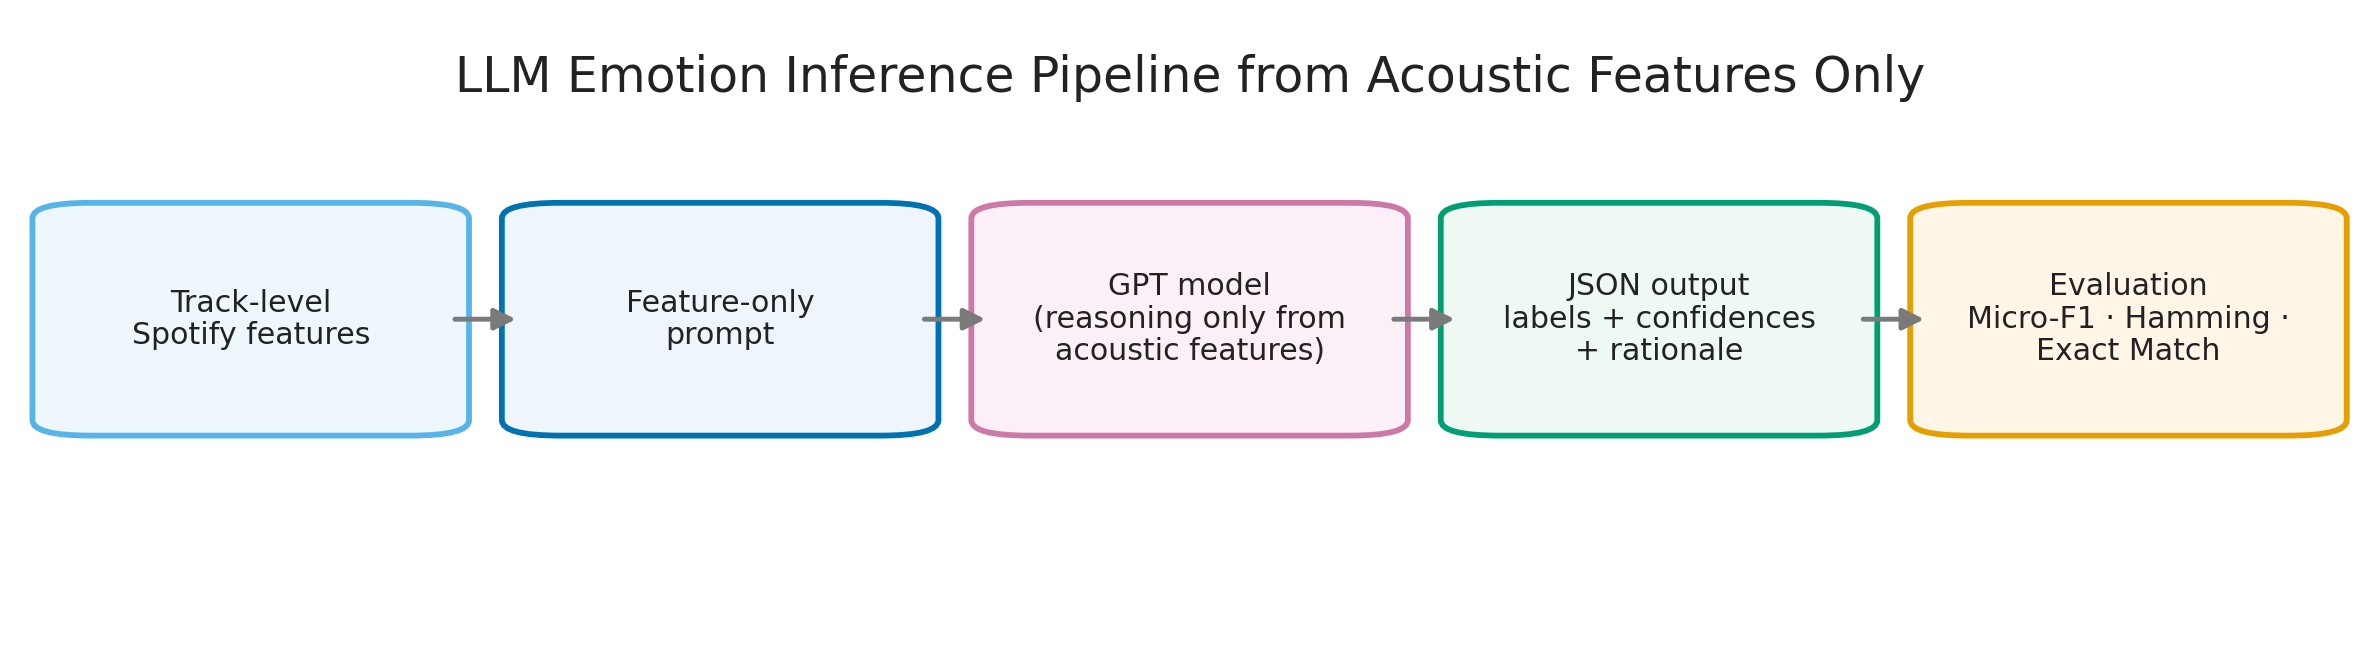

In [39]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(15, 4.2))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Slightly softer fills + strong borders
boxes = [
    {
        "text": "Track-level\nSpotify features",
        "x": 0.10,
        "edge": CB["sky"],
        "face": "#EEF7FC"
    },
    {
        "text": "Feature-only\nprompt",
        "x": 0.30,
        "edge": CB["blue"],
        "face": "#EEF5FB"
    },
    {
        "text": "GPT model\n(reasoning only from\nacoustic features)",
        "x": 0.50,
        "edge": CB["purple"],
        "face": "#FBF0F7"
    },
    {
        "text": "JSON output\nlabels + confidences\n+ rationale",
        "x": 0.70,
        "edge": CB["green"],
        "face": "#EEF9F4"
    },
    {
        "text": "Evaluation\nMicro-F1 · Hamming ·\nExact Match",
        "x": 0.90,
        "edge": CB["orange"],
        "face": "#FFF6E8"
    },
]

box_w = 0.15
box_h = 0.34
y0 = 0.34

for b in boxes:
    rect = FancyBboxPatch(
        (b["x"] - box_w / 2, y0),
        box_w,
        box_h,
        boxstyle="round,pad=0.018,rounding_size=0.025",
        linewidth=2.6,
        edgecolor=b["edge"],
        facecolor=b["face"]
    )
    ax.add_patch(rect)

    ax.text(
        b["x"], y0 + box_h / 2,
        b["text"],
        ha="center", va="center",
        fontsize=13.5,
        color=CB["black"],
        linespacing=1.15
    )

# arrows
for i in range(len(boxes) - 1):
    x1 = boxes[i]["x"] + box_w / 2 + 0.012
    x2 = boxes[i + 1]["x"] - box_w / 2 - 0.012

    arrow = FancyArrowPatch(
        (x1, y0 + box_h / 2),
        (x2, y0 + box_h / 2),
        arrowstyle="-|>",
        mutation_scale=20,
        linewidth=2.2,
        color="#7A7A7A",
        shrinkA=0,
        shrinkB=0
    )
    ax.add_patch(arrow)

# title
ax.text(
    0.5, 0.90,
    "LLM Emotion Inference Pipeline from Acoustic Features Only",
    ha="center", va="center",
    fontsize=22,
    color=CB["black"]
)

plt.tight_layout()
plt.show()

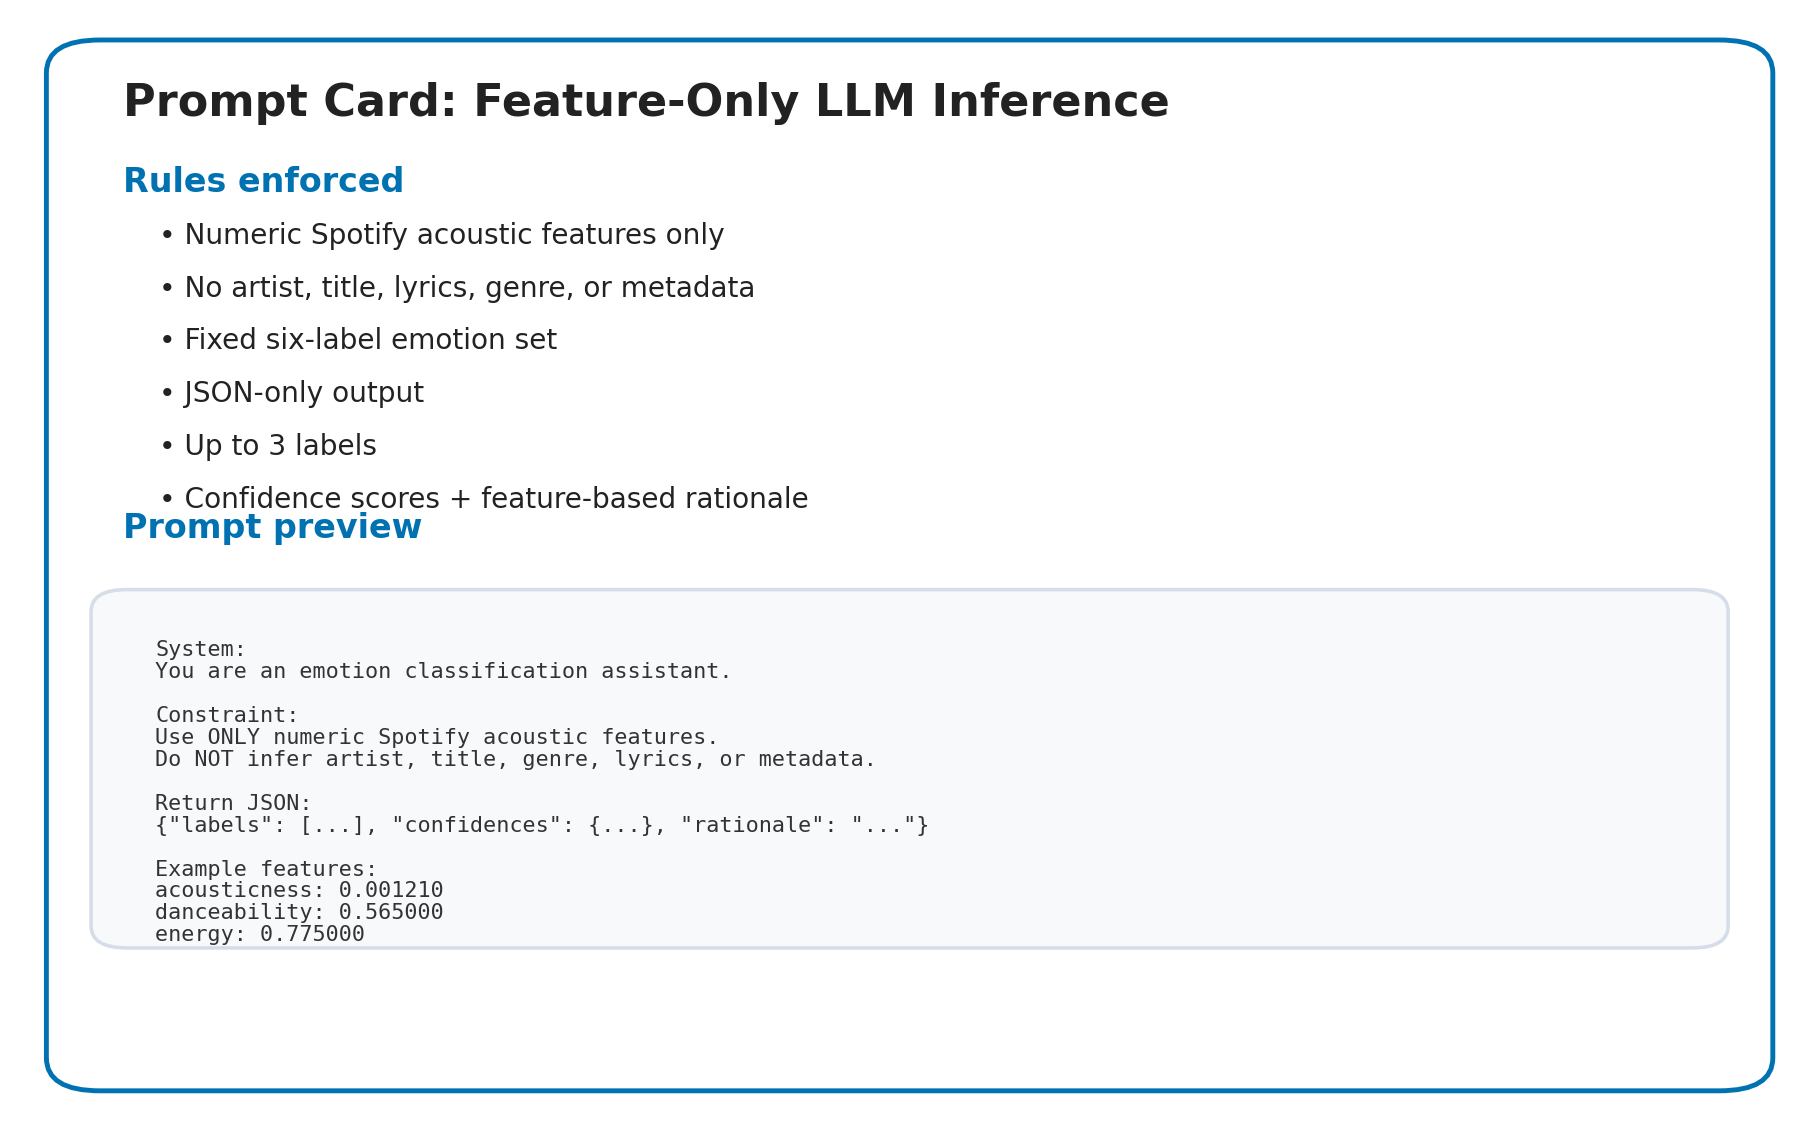

In [45]:
example_row = df_track.iloc[0]

preview_lines = [
    "System:",
    "You are an emotion classification assistant.",
    "",
    "Constraint:",
    "Use ONLY numeric Spotify acoustic features.",
    "Do NOT infer artist, title, genre, lyrics, or metadata.",
    "",
    "Return JSON:",
    '{"labels": [...], "confidences": {...}, "rationale": "..."}',
    "",
    "Example features:",
    f"acousticness: {example_row['acousticness']:.6f}",
    f"danceability: {example_row['danceability']:.6f}",
    f"energy: {example_row['energy']:.6f}",
]

snippet = "\n".join(preview_lines)

fig, ax = plt.subplots(figsize=(11.5, 7.2))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Outer card
card = FancyBboxPatch(
    (0.035, 0.04), 0.93, 0.92,
    boxstyle="round,pad=0.018,rounding_size=0.03",
    linewidth=2.2,
    edgecolor=CB["blue"],
    facecolor="white"
)
ax.add_patch(card)

# Title
ax.text(
    0.06, 0.92,
    "Prompt Card: Feature-Only LLM Inference",
    fontsize=20,
    fontweight="bold",
    color=CB["black"],
    va="center"
)

# Rules header
ax.text(
    0.06, 0.84,
    "Rules enforced",
    fontsize=15,
    fontweight="bold",
    color=CB["blue"]
)

rules = [
    "Numeric Spotify acoustic features only",
    "No artist, title, lyrics, genre, or metadata",
    "Fixed six-label emotion set",
    "JSON-only output",
    "Up to 3 labels",
    "Confidence scores + feature-based rationale",
]

y = 0.80
for r in rules:
    ax.text(
        0.08, y,
        f"• {r}",
        fontsize=12.6,
        color=CB["black"],
        va="center"
    )
    y -= 0.048

# Prompt preview header
ax.text(
    0.06, 0.525,
    "Prompt preview",
    fontsize=15,
    fontweight="bold",
    color=CB["blue"]
)

# Preview box: slightly taller
code_x, code_y, code_w, code_h = 0.06, 0.17, 0.88, 0.29

code_box = FancyBboxPatch(
    (code_x, code_y), code_w, code_h,
    boxstyle="round,pad=0.018,rounding_size=0.02",
    linewidth=1.6,
    edgecolor="#D5DEE8",
    facecolor="#F7F9FB"
)
ax.add_patch(code_box)

# Text placed a little higher inside the box
txt = ax.text(
    code_x + 0.018,               # left padding
    code_y + code_h - 0.028,      # top padding
    snippet,
    family="monospace",
    fontsize=9.8,
    color="#333333",
    va="top",
    linespacing=1.12
)
txt.set_clip_path(code_box)

plt.tight_layout()
plt.show()

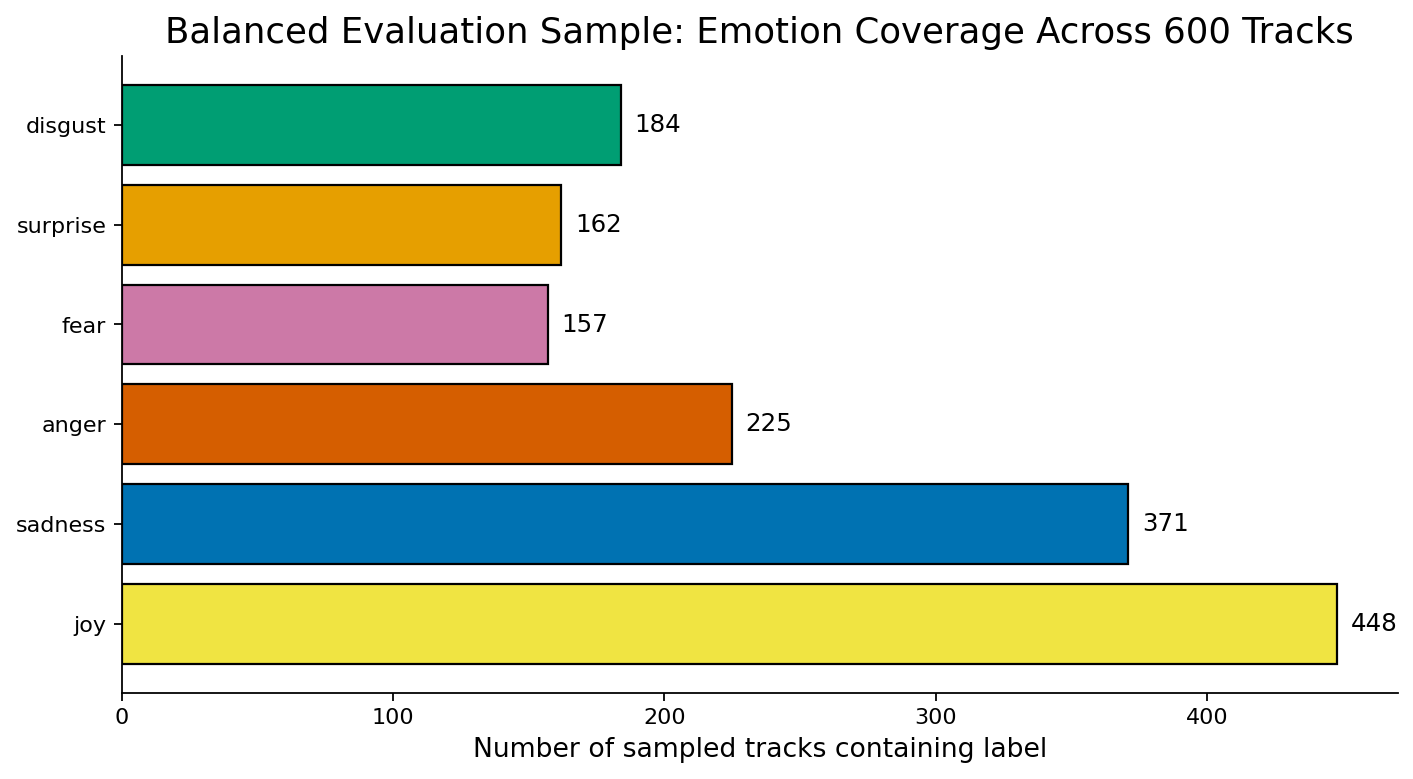

In [29]:
sample_series = pd.Series(sample_counts).reindex(EMOTIONS)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    sample_series.index,
    sample_series.values,
    color=[EMOTION_COLORS[e] for e in sample_series.index],
    edgecolor="black"
)

for bar, val in zip(bars, sample_series.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, str(val), va="center")

ax.set_title("Balanced Evaluation Sample: Emotion Coverage Across 600 Tracks")
ax.set_xlabel("Number of sampled tracks containing label")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

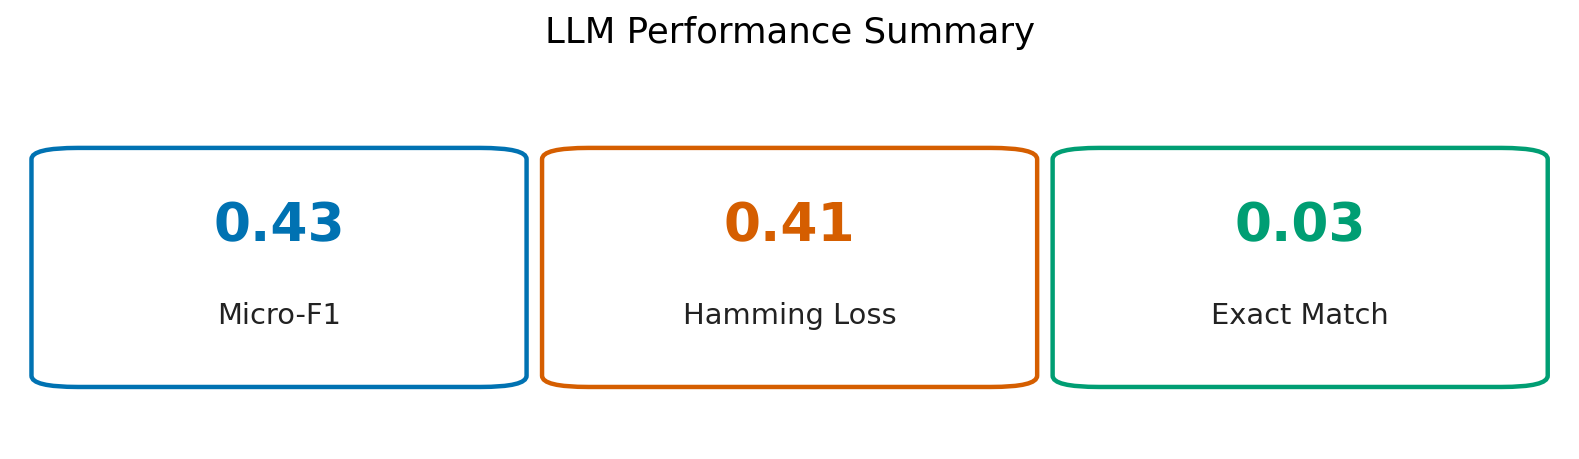

In [30]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")

tiles = [
    ("Micro-F1", round(micro_f1, 2), CB["blue"]),
    ("Hamming Loss", round(ham, 2), CB["red"]),
    ("Exact Match", round(exact, 2), CB["green"]),
]

xs = [0.17, 0.50, 0.83]
for (label, value, color), x in zip(tiles, xs):
    rect = FancyBboxPatch(
        (x-0.13, 0.18), 0.26, 0.58,
        boxstyle="round,pad=0.03,rounding_size=0.03",
        linewidth=2, edgecolor=color, facecolor="white"
    )
    ax.add_patch(rect)
    ax.text(x, 0.58, f"{value:.2f}", ha="center", va="center",
            fontsize=24, fontweight="bold", color=color)
    ax.text(x, 0.34, label, ha="center", va="center",
            fontsize=13, color=CB["black"])

ax.set_title("LLM Performance Summary", pad=12)
plt.tight_layout()
plt.show()

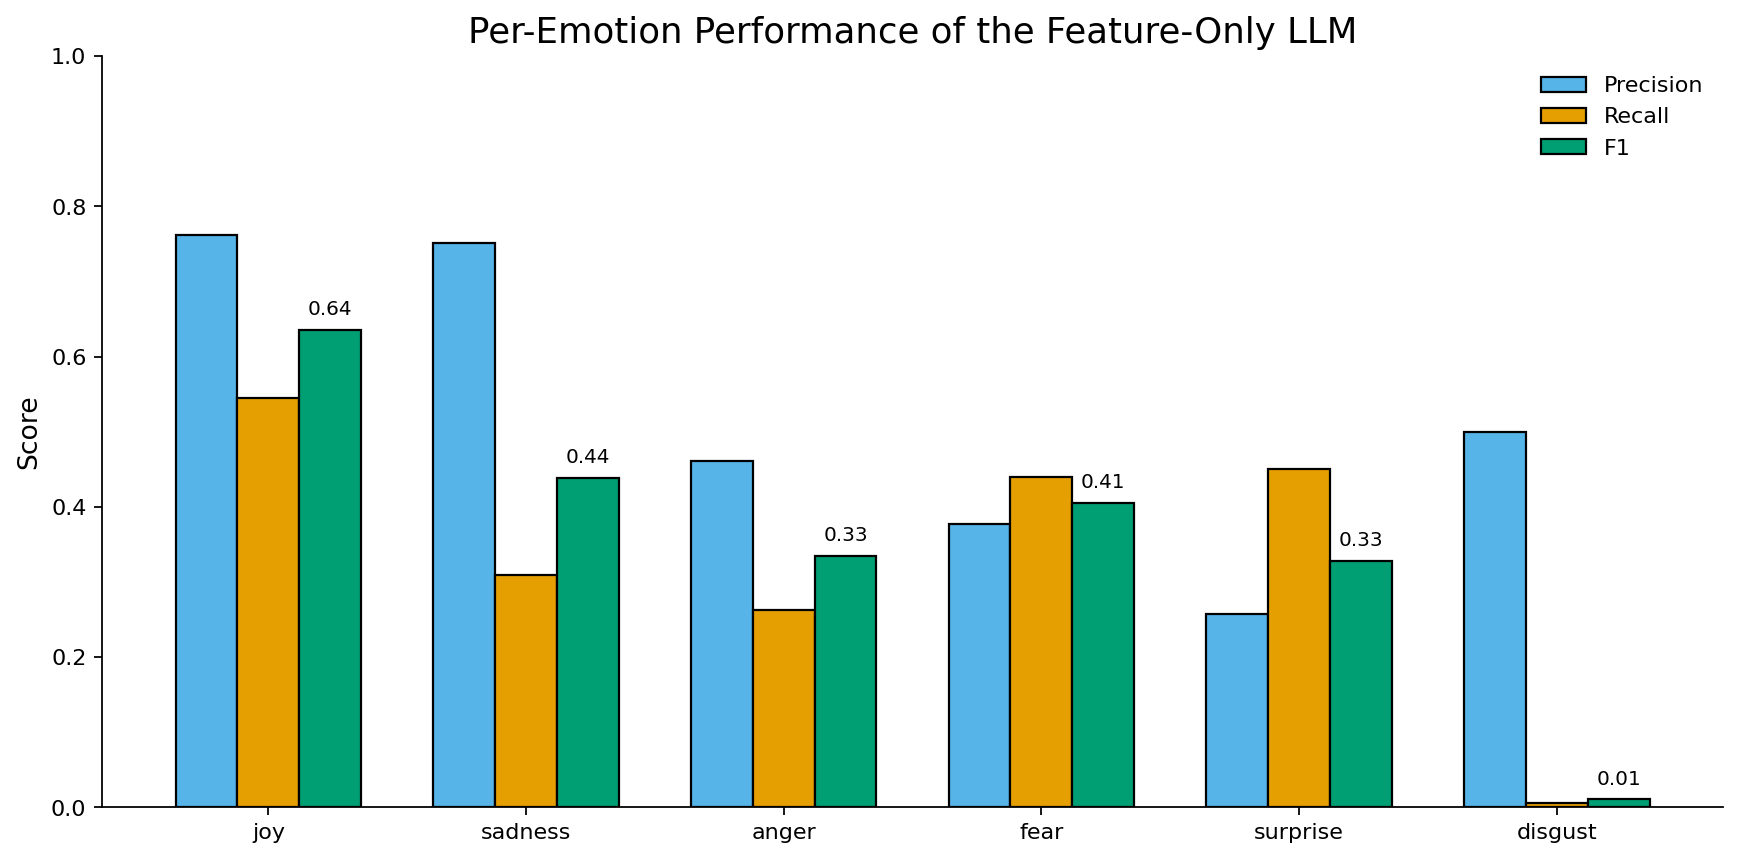

In [31]:
report = classification_report(
    Y_true, Y_pred,
    target_names=EMOTIONS,
    output_dict=True,
    zero_division=0
)

metrics_df = pd.DataFrame({
    e: {
        "precision": report[e]["precision"],
        "recall": report[e]["recall"],
        "f1-score": report[e]["f1-score"]
    }
    for e in EMOTIONS
}).T.reset_index().rename(columns={"index": "emotion"})

x = np.arange(len(metrics_df))
w = 0.24

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x - w, metrics_df["precision"], width=w, label="Precision", color=CB["sky"], edgecolor="black")
ax.bar(x,     metrics_df["recall"],    width=w, label="Recall",    color=CB["orange"], edgecolor="black")
ax.bar(x + w, metrics_df["f1-score"],  width=w, label="F1",        color=CB["green"], edgecolor="black")

ax.set_xticks(x)
ax.set_xticklabels(metrics_df["emotion"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Per-Emotion Performance of the Feature-Only LLM")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, row in metrics_df.iterrows():
    ax.text(i + w, row["f1-score"] + 0.02, f"{row['f1-score']:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

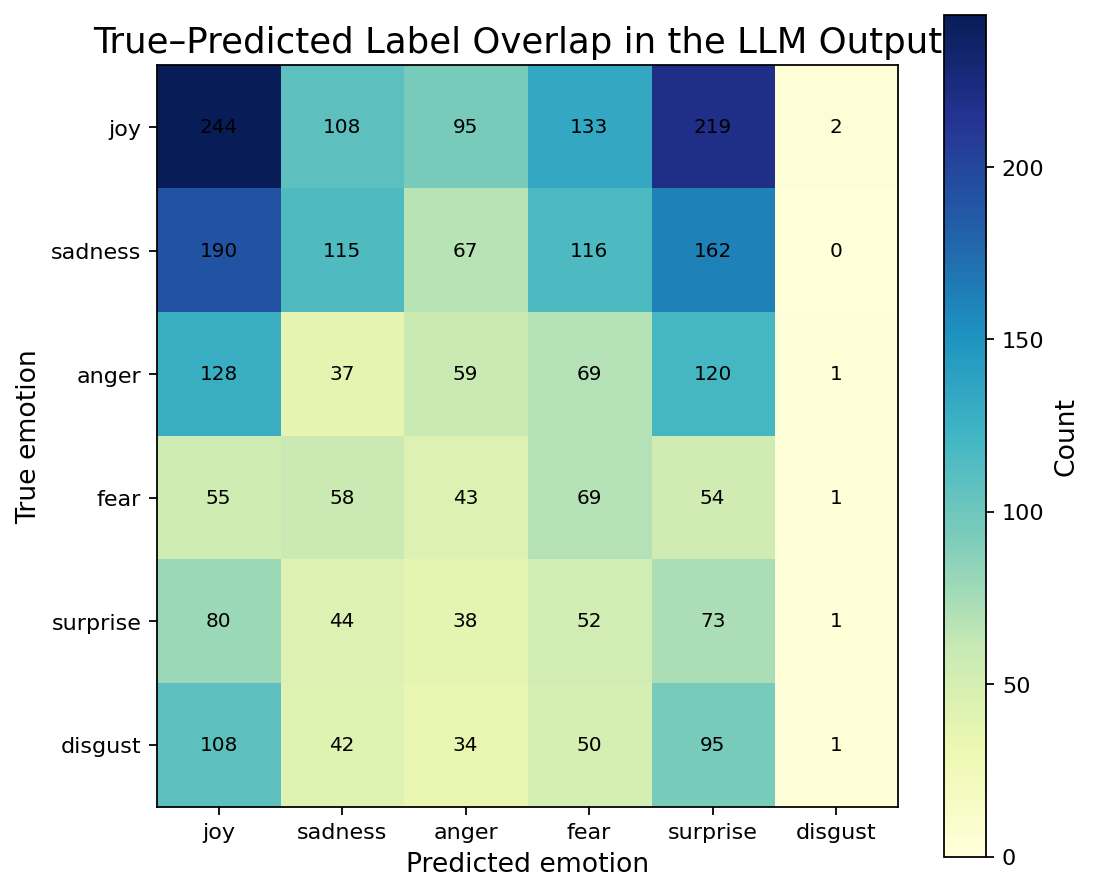

In [32]:
overlap = pd.DataFrame(0, index=EMOTIONS, columns=EMOTIONS)

for _, row in results_df.iterrows():
    true_labs = row["true_labels"]
    pred_labs = row["pred_labels"]
    for t in true_labs:
        for p in pred_labs:
            if t in EMOTIONS and p in EMOTIONS:
                overlap.loc[t, p] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(overlap.values, cmap="YlGnBu")

ax.set_xticks(np.arange(len(EMOTIONS)))
ax.set_yticks(np.arange(len(EMOTIONS)))
ax.set_xticklabels(EMOTIONS)
ax.set_yticklabels(EMOTIONS)
ax.set_xlabel("Predicted emotion")
ax.set_ylabel("True emotion")
ax.set_title("True–Predicted Label Overlap in the LLM Outputs")

for i in range(len(EMOTIONS)):
    for j in range(len(EMOTIONS)):
        ax.text(j, i, overlap.values[i, j], ha="center", va="center", color="black", fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Count")
plt.tight_layout()
plt.show()

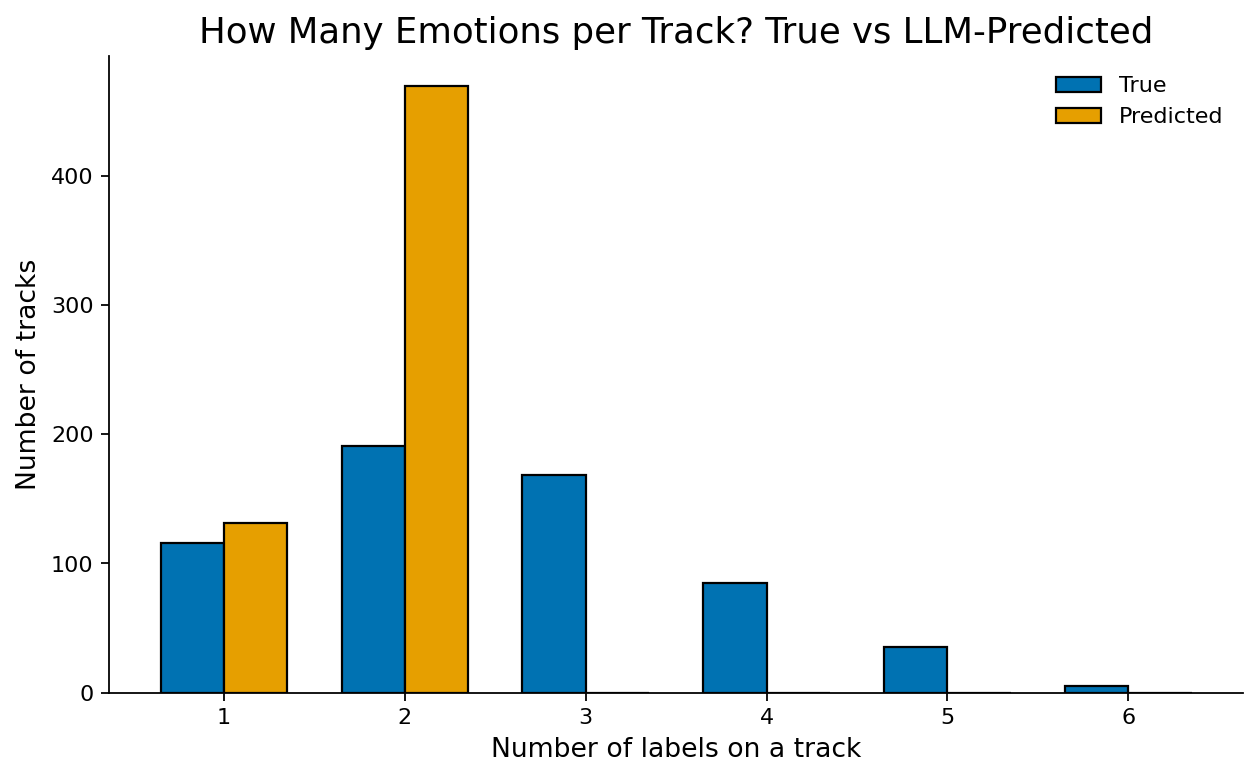

In [33]:
count_df = pd.DataFrame({
    "True labels per track": results_df["n_true"].value_counts().sort_index(),
    "Predicted labels per track": results_df["n_pred"].value_counts().sort_index()
}).fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(count_df.index))
w = 0.35

ax.bar(x - w/2, count_df["True labels per track"], width=w, color=CB["blue"], label="True", edgecolor="black")
ax.bar(x + w/2, count_df["Predicted labels per track"], width=w, color=CB["orange"], label="Predicted", edgecolor="black")

ax.set_xticks(x)
ax.set_xticklabels(count_df.index.astype(int))
ax.set_xlabel("Number of labels on a track")
ax.set_ylabel("Number of tracks")
ax.set_title("How Many Emotions per Track? True vs LLM-Predicted")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

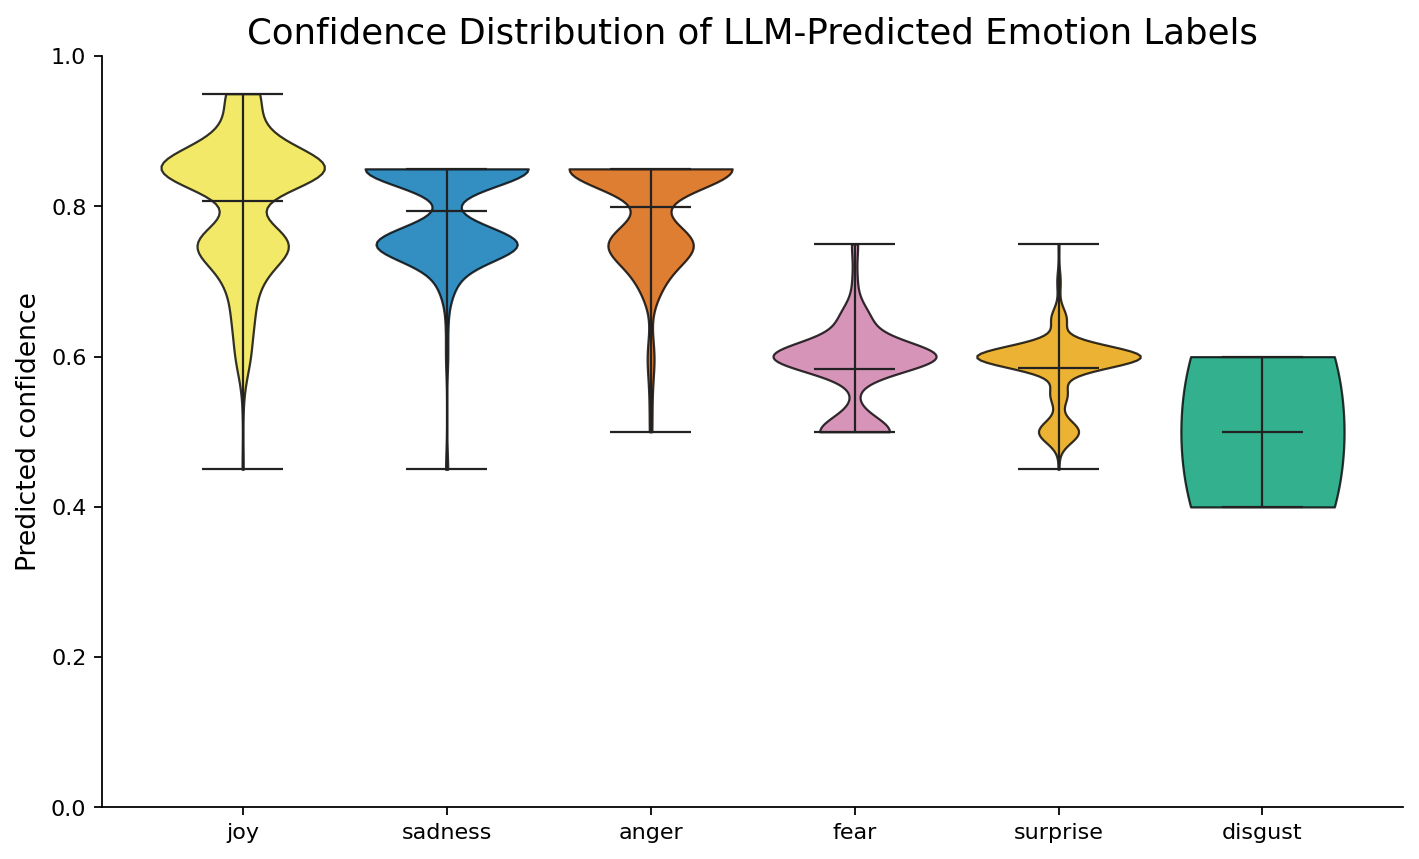

In [34]:
conf_rows = []
for _, row in results_df.iterrows():
    confs = row["confidences"]
    for emotion, val in confs.items():
        if emotion in EMOTIONS:
            conf_rows.append({"emotion": emotion, "confidence": float(val)})

conf_df = pd.DataFrame(conf_rows)

fig, ax = plt.subplots(figsize=(9, 5.5))
data = [conf_df.loc[conf_df["emotion"] == e, "confidence"].values for e in EMOTIONS]

parts = ax.violinplot(data, showmeans=True, showmedians=False, widths=0.8)
for i, body in enumerate(parts["bodies"]):
    body.set_facecolor(EMOTION_COLORS[EMOTIONS[i]])
    body.set_edgecolor("black")
    body.set_alpha(0.8)

for partname in ("cbars", "cmins", "cmaxes", "cmeans"):
    if partname in parts:
        parts[partname].set_edgecolor(CB["black"])
        parts[partname].set_linewidth(1)

ax.set_xticks(np.arange(1, len(EMOTIONS) + 1))
ax.set_xticklabels(EMOTIONS)
ax.set_ylim(0, 1)
ax.set_ylabel("Predicted confidence")
ax.set_title("Confidence Distribution of LLM-Predicted Emotion Labels")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

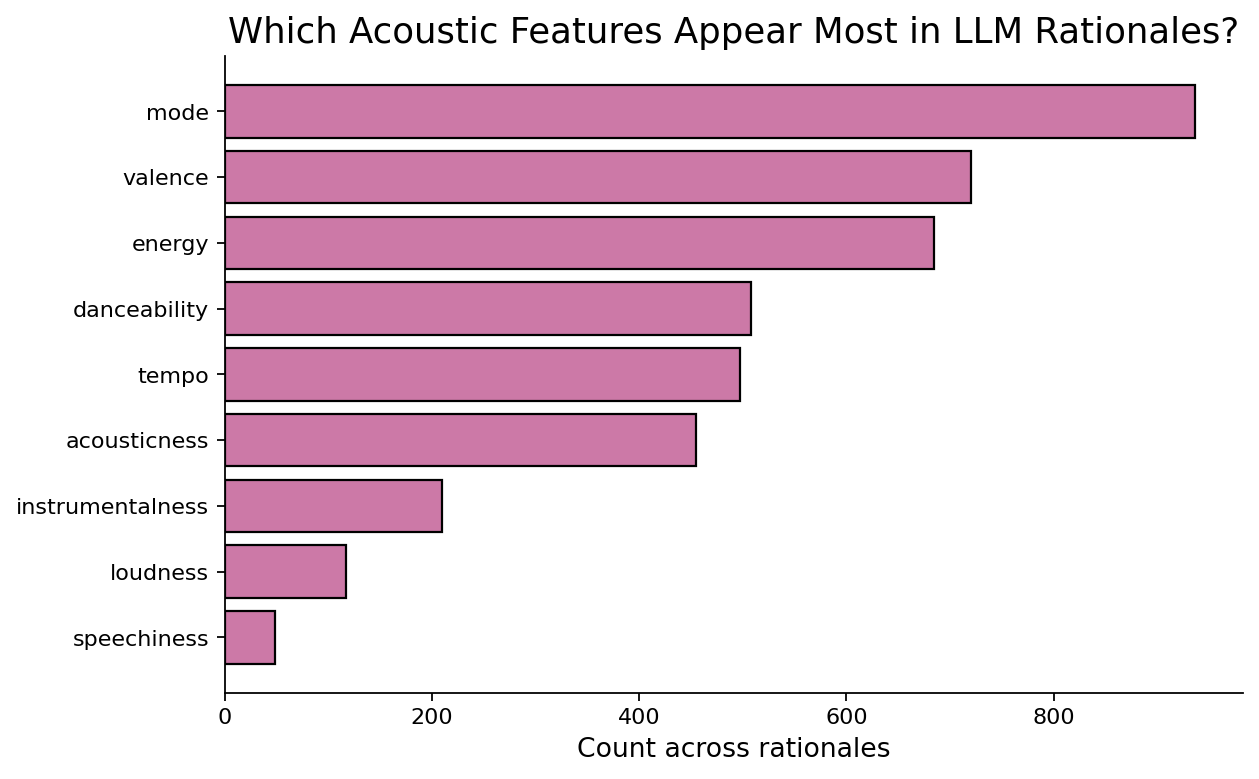

In [35]:
KEY_TERMS = ["valence", "energy", "tempo", "loudness", "danceability",
             "acousticness", "speechiness", "instrumentalness", "mode"]

term_counts = {term: 0 for term in KEY_TERMS}

for txt in results_df["rationale"].fillna("").astype(str):
    txt_low = txt.lower()
    for term in KEY_TERMS:
        term_counts[term] += txt_low.count(term)

term_series = pd.Series(term_counts).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(term_series.index, term_series.values, color=CB["purple"], edgecolor="black")
ax.set_title("Which Acoustic Features Appear Most in LLM Rationales?")
ax.set_xlabel("Count across rationales")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

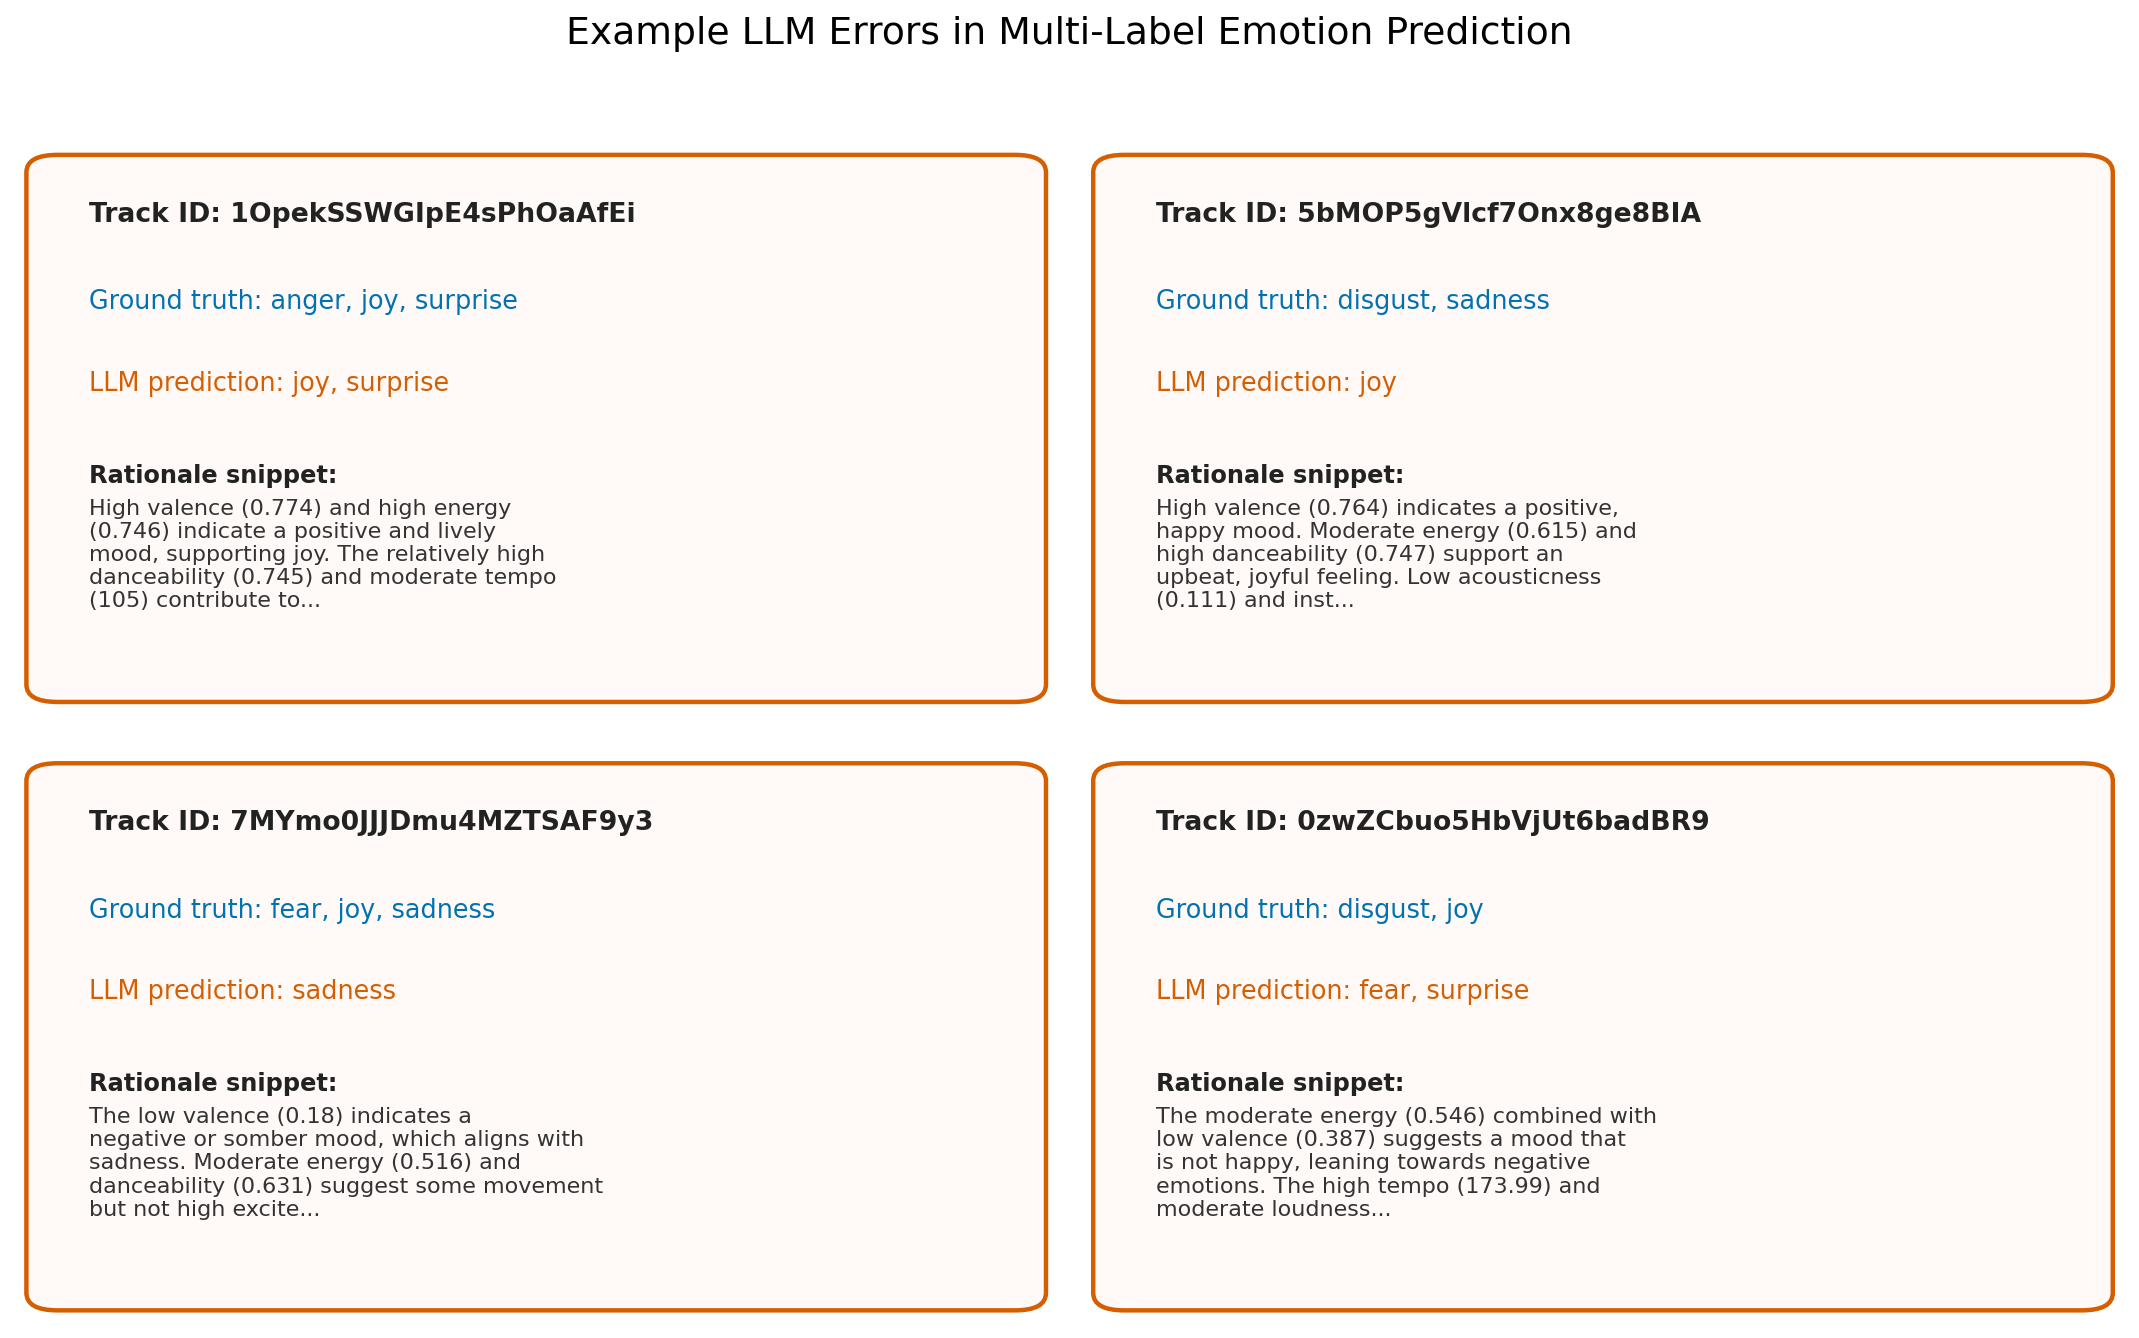

In [47]:
import textwrap
import math

mistakes = results_df[results_df["true_labels"] != results_df["pred_labels"]].copy().head(4)

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.5))
axes = axes.flatten()

def wrap_text(s, width):
    return "\n".join(textwrap.wrap(str(s), width=width, break_long_words=False))

for ax, (_, row) in zip(axes, mistakes.iterrows()):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # Card background
    box = FancyBboxPatch(
        (0.03, 0.04), 0.94, 0.90,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        linewidth=2.0,
        edgecolor=CB["red"],
        facecolor="#FFF9F7"
    )
    ax.add_patch(box)

    # Clean text fields
    track_id = str(row["track_id"])
    if len(track_id) > 24:
        track_id = track_id[:24] + "..."

    true_txt = ", ".join(row["true_labels"])
    pred_txt = ", ".join(row["pred_labels"])

    rat = str(row["rationale"]).strip()
    if len(rat) > 180:
        rat = rat[:177] + "..."
    rat = wrap_text(rat, width=42)

    # Text objects
    t1 = ax.text(
        0.07, 0.88,
        f"Track ID: {track_id}",
        fontsize=12,
        fontweight="bold",
        color=CB["black"],
        va="top"
    )

    t2 = ax.text(
        0.07, 0.73,
        f"Ground truth: {true_txt}",
        fontsize=11.5,
        color=CB["blue"],
        va="top"
    )

    t3 = ax.text(
        0.07, 0.59,
        f"LLM prediction: {pred_txt}",
        fontsize=11.5,
        color=CB["red"],
        va="top"
    )

    t4 = ax.text(
        0.07, 0.43,
        "Rationale snippet:",
        fontsize=10.8,
        fontweight="bold",
        color=CB["black"],
        va="top"
    )

    t5 = ax.text(
        0.07, 0.37,
        rat,
        fontsize=10,
        color="#333333",
        va="top",
        linespacing=1.2
    )

    # Clip all text to the card
    for t in [t1, t2, t3, t4, t5]:
        t.set_clip_path(box)

# Hide unused axes if fewer than 4 mistakes
for j in range(len(mistakes), len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Example LLM Errors in Multi-Label Emotion Prediction",
    fontsize=17,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

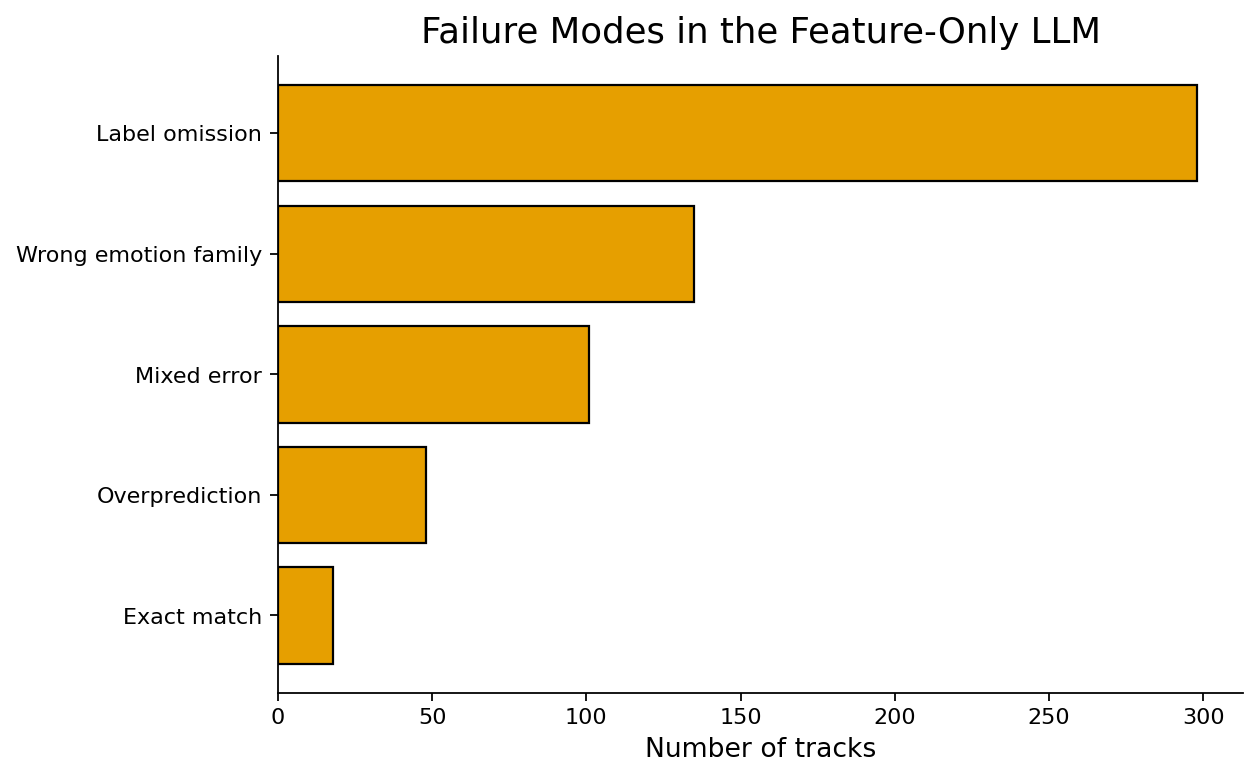

In [37]:
def classify_failure(row):
    true_set = set(row["true_labels"])
    pred_set = set(row["pred_labels"])

    if pred_set == true_set:
        return "Exact match"
    if len(pred_set) < len(true_set) and len(true_set & pred_set) > 0:
        return "Label omission"
    if len(pred_set) > len(true_set) and len(true_set & pred_set) > 0:
        return "Overprediction"
    if len(true_set & pred_set) == 0 and len(pred_set) > 0:
        return "Wrong emotion family"
    if len(pred_set) == 0:
        return "No prediction"
    return "Mixed error"

results_df["failure_type"] = results_df.apply(classify_failure, axis=1)
fail_counts = results_df["failure_type"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fail_counts.index[::-1], fail_counts.values[::-1], color=CB["orange"], edgecolor="black")
ax.set_title("Failure Modes in the Feature-Only LLM")
ax.set_xlabel("Number of tracks")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

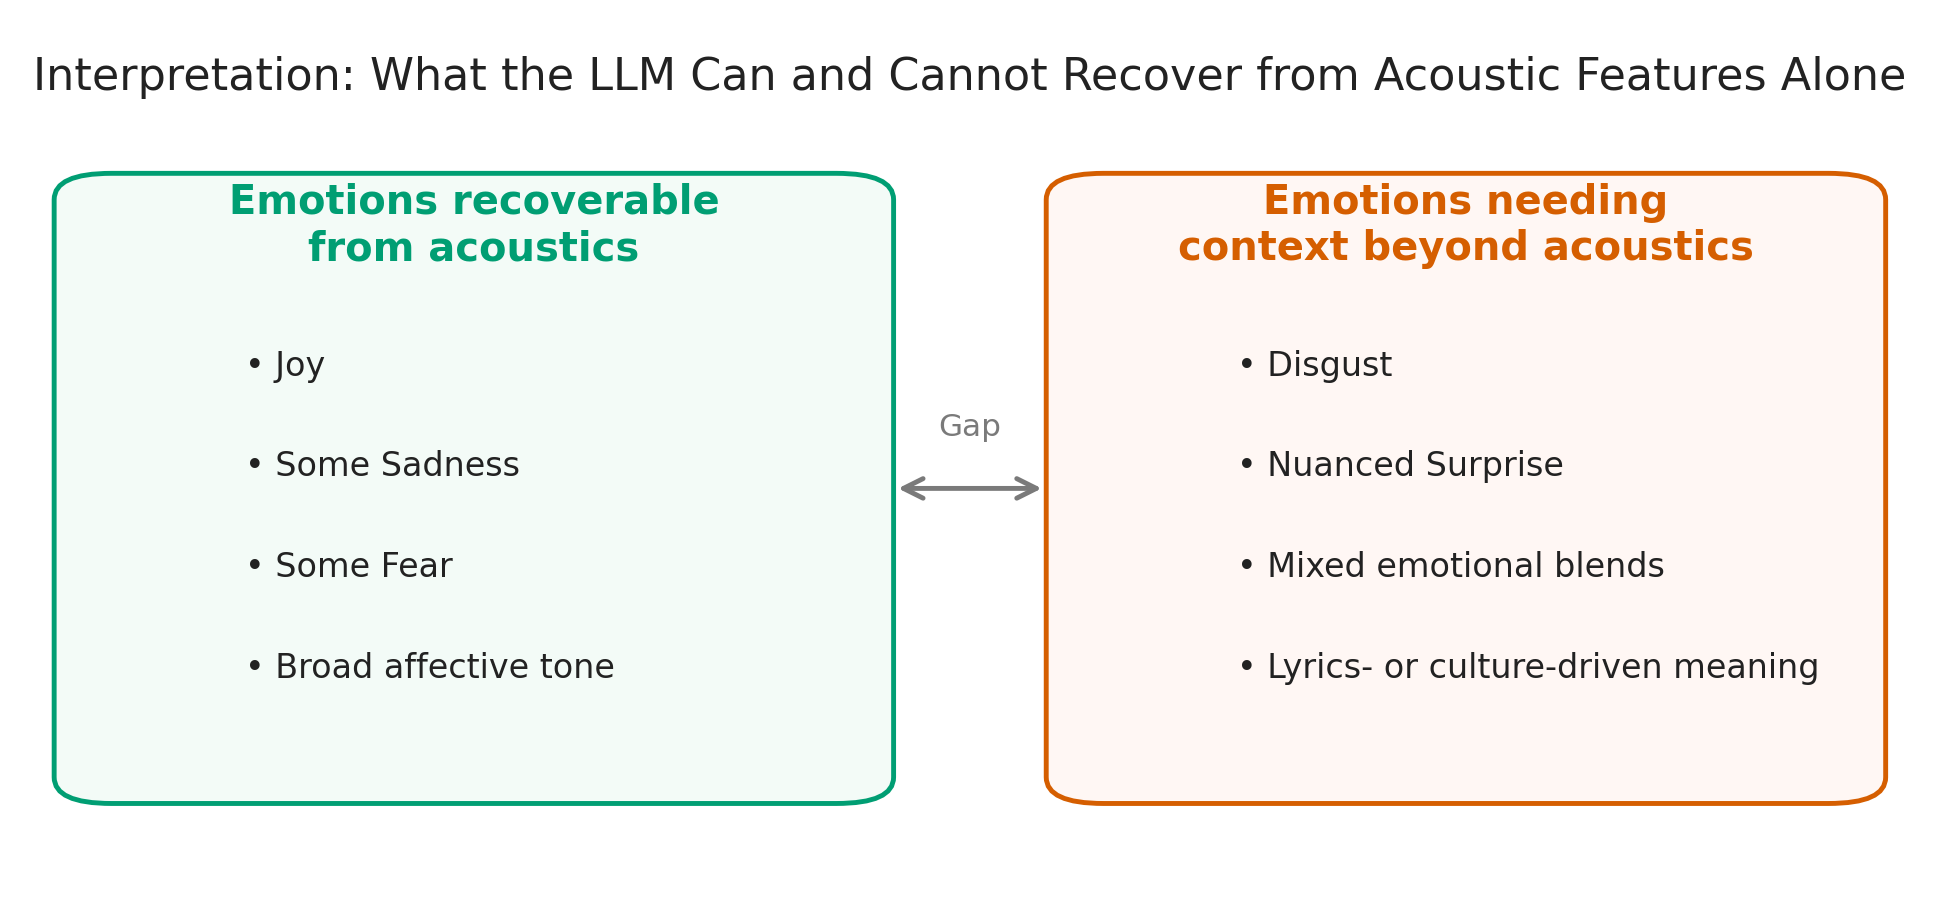

In [48]:
# Cleaner interpretation figure:
# - better spacing
# - smaller, more balanced title
# - headers sit comfortably inside the boxes
# - softer fills and cleaner center gap annotation
# - bullets aligned more consistently

fig, ax = plt.subplots(figsize=(13.5, 5.8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Colors
left_edge = CB["green"]
left_face = "#F3FBF7"
right_edge = CB["red"]
right_face = "#FFF7F4"
mid_color = "#7A7A7A"

# Boxes
left_x, left_y, left_w, left_h = 0.05, 0.13, 0.38, 0.66
right_x, right_y, right_w, right_h = 0.57, 0.13, 0.38, 0.66

left = FancyBboxPatch(
    (left_x, left_y), left_w, left_h,
    boxstyle="round,pad=0.03,rounding_size=0.03",
    linewidth=2.2, edgecolor=left_edge, facecolor=left_face
)
right = FancyBboxPatch(
    (right_x, right_y), right_w, right_h,
    boxstyle="round,pad=0.03,rounding_size=0.03",
    linewidth=2.2, edgecolor=right_edge, facecolor=right_face
)
ax.add_patch(left)
ax.add_patch(right)

# Main title
ax.text(
    0.5, 0.93,
    "Interpretation: What the LLM Can and Cannot Recover from Acoustic Features Alone",
    ha="center", va="center",
    fontsize=20, color=CB["black"]
)

# Section headers
ax.text(
    left_x + left_w/2, 0.76,
    "Emotions recoverable\nfrom acoustics",
    ha="center", va="center",
    fontsize=18, fontweight="bold", color=left_edge
)
ax.text(
    right_x + right_w/2, 0.76,
    "Emotions needing\ncontext beyond acoustics",
    ha="center", va="center",
    fontsize=18, fontweight="bold", color=right_edge
)

# Bullet content
left_items = [
    "Joy",
    "Some Sadness",
    "Some Fear",
    "Broad affective tone"
]
right_items = [
    "Disgust",
    "Nuanced Surprise",
    "Mixed emotional blends",
    "Lyrics- or culture-driven meaning"
]

left_start_y = 0.60
right_start_y = 0.60
step = 0.115

for i, item in enumerate(left_items):
    ax.text(
        left_x + 0.07, left_start_y - i*step,
        f"• {item}",
        fontsize=15, color=CB["black"],
        va="center"
    )

for i, item in enumerate(right_items):
    ax.text(
        right_x + 0.07, right_start_y - i*step,
        f"• {item}",
        fontsize=15, color=CB["black"],
        va="center"
    )

# Gap arrow and label
arrow = FancyArrowPatch(
    (0.46, 0.46), (0.54, 0.46),
    arrowstyle="<->",
    mutation_scale=22,
    linewidth=2.2,
    color=mid_color
)
ax.add_patch(arrow)

ax.text(
    0.50, 0.53,
    "Gap",
    ha="center", va="center",
    fontsize=14, color=mid_color
)

plt.tight_layout()
plt.show()